In [1]:
'''
EDA

Not a clear target to use for this data but let's play around with it and make some hypothetical ones
then do some analysis on them

'''

"\nEDA\n\nNot a clear target to use for this data but let's play around with it and make some hypothetical ones\nthen do some analysis on them\n\n"

In [2]:
import pandas as pd
import numpy as np

import sys
sys.path.append('..')

import eda_utils_sgo
import eda_utils_nlp
import eda_utils_dedupe
import eda_utils_treatment
from eda_utils_topics import lda_sklearn, nmf_sklearn, lda_gensim, nmf_gensim


pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 300)

In [3]:
%load_ext autoreload
%autoreload 2

## Load Data and Treat Data

In [4]:
from pathlib import Path
repo_root = Path.cwd().parents[1]  # eda/ADS_to_2026_03_16 -> repo root
data_dir = repo_root / 'data' / 'nhtsa'
paths = [
    data_dir / 'SGO-2021-01_Incident_Reports_ADS_to_2025_06_16.csv',
    data_dir / 'SGO-2021-01_Incident_Reports_ADS_2025_06_16_to_2026_03_16.csv',
]

In [5]:
ads_df = eda_utils_sgo.load_and_concat_csvs(paths)

Only in SGO-2021-01_Incident_Reports_ADS_to_2025_06_16.csv:
  ADAS/ADS Hardware Version
  ADAS/ADS Hardware Version - Unk
  ADAS/ADS Hardware Version CBI
  ADAS/ADS Software Version
  ADAS/ADS Software Version - Unk
  ADAS/ADS Software Version CBI
  ADAS/ADS System Version
  ADAS/ADS System Version - Unk
  ADAS/ADS System Version CBI
  ADS Equipped?
  CP Any Air Bags Deployed?
  CP Was Vehicle Towed?
  Federal Reg. Exemption - No
  Federal Reg. Exemption - Unk
  Federal Regulatory Exemption?
  Inv. Officer Email - Unknown
  Inv. Officer Name - Unknown
  Inv. Officer Phone - Unknown
  Investigating Officer Email
  Investigating Officer Name
  Investigating Officer Phone
  Law Enforcement Investigating?
  Lighting
  Mileage
  Mileage - Unknown
  Notice Received Date
  Other Federal Reg. Exemption
  Other Reporting Entities?
  Other Reporting Entities? - NA
  Other Reporting Entities? - Unk
  Posted Speed Limit (MPH)
  Posted Speed Limit - Unknown
  Property Damage?
  Rep Ent Or Mfr Inves

In [6]:
entity_column = 'master_entity'

In [7]:
# add overall entity and drop duplicates

treated_df = eda_utils_dedupe.dedupe_same_incident(ads_df.copy(), verbose=True)

# to do: more treatment of various columns

treated_df = eda_utils_treatment.apply_all_treatments(treated_df)

new_cols = [c for c in treated_df.columns if c not in ads_df.columns]
print(new_cols)
treated_df[['Operating Entity', 'Operating Entity Clean',
        'Reporting Entity', 'Reporting Entity Clean',
        'master_entity',
        'Make', 'Model', 'Make Model',
        'State', 'State Clean']].head(10)




dedupe_same_incident: 3120 -> 2344 rows (776 duplicates collapsed)
['Narrative - Same Incident ID', 'Operating Entity Clean', 'Reporting Entity Clean', 'Investigating Agency Clean', 'State or Local Permit Clean', 'Make Clean', 'Model Clean', 'State Clean', 'master_entity', 'Make Model']


,Operating Entity,Operating Entity Clean,Reporting Entity,Reporting Entity Clean,master_entity,Make,Model,Make Model,State,State Clean
0,Waymo LLC,waymo,Waymo LLC,waymo,Waymo,JAGUAR,I-PACE,jaguar | i pace,CA,CA
1,Zoox,zoox,"Zoox, Inc.",zoox,Zoox,ZOOX,Zoox,zoox | zoox,NV,NV
2,Zoox,zoox,"Zoox, Inc.",zoox,Zoox,TOYOTA,Highlander,toyota | highlander,CA,CA
3,"Aurora Operations, Inc.",aurora operations,"Aurora Operations, Inc.",aurora operations,Aurora Operations,PETERBILT,579,peterbilt | 579,TX,TX
4,"Beep, Inc.",beep,"Beep, Inc.",beep,Beep,FORD,Transit,ford | transit,FL,FL
5,May Mobility Inc.,may mobility,May Mobility,may mobility,MAY Mobility,TOYOTA,Sienna,toyota | sienna,MN,MN
6,May Mobility Inc.,may mobility,May Mobility,may mobility,MAY Mobility,TOYOTA,Sienna,toyota | sienna,GA,GA
7,Nuro,nuro,Nuro,nuro,Nuro,TOYOTA,Prius,toyota | prius,TX,TX
8,Waymo LLC,waymo,Waymo LLC,waymo,Waymo,JAGUAR,I-PACE,jaguar | i pace,CA,CA
9,Waymo LLC,waymo,Waymo LLC,waymo,Waymo,JAGUAR,I-PACE,jaguar | i pace,CA,CA


In [8]:
earlier_df = pd.read_csv(paths[0])
print(earlier_df.shape)
earlier_df.columns.to_list()

(2295, 137)


['Report ID',
 'Report Version',
 'Reporting Entity',
 'Report Type',
 'Report Month',
 'Report Year',
 'Report Submission Date',
 'VIN',
 'VIN - Unknown',
 'Serial Number',
 'Make',
 'Model',
 'Model - Unknown',
 'Model Year',
 'Model Year - Unknown',
 'Same Vehicle ID',
 'Mileage',
 'Mileage - Unknown',
 'Driver / Operator Type',
 'ADAS/ADS System Version',
 'ADAS/ADS System Version - Unk',
 'ADAS/ADS System Version CBI',
 'ADAS/ADS Hardware Version',
 'ADAS/ADS Hardware Version - Unk',
 'ADAS/ADS Hardware Version CBI',
 'ADAS/ADS Software Version',
 'ADAS/ADS Software Version - Unk',
 'ADAS/ADS Software Version CBI',
 'Other Reporting Entities?',
 'Other Reporting Entities? - Unk',
 'Other Reporting Entities? - NA',
 'Federal Regulatory Exemption?',
 'Other Federal Reg. Exemption',
 'Federal Reg. Exemption - Unk',
 'Federal Reg. Exemption - No',
 'State or Local Permit?',
 'State or Local Permit',
 'ADS Equipped?',
 'Automation System Engaged?',
 'Operating Entity',
 'Operating Enti

In [9]:
later_df = pd.read_csv(paths[1])
print(later_df.shape)
later_df.columns.to_list()

(825, 116)


['Report ID',
 'Report Version',
 'Reporting Entity',
 'Report Type',
 'Report Month',
 'Report Year',
 'Report Submission Date',
 'VIN',
 'VIN Decoded',
 'Serial Number',
 'Make',
 'Make - Unknown',
 'Model',
 'Model - Unknown',
 'Model Year',
 'Model Year - Unknown',
 'Same Vehicle ID',
 'Driver / Operator Type',
 'Automation Feature Version',
 'Automation Feature Version CBI',
 'Automation System Engaged?',
 'Engagement Status',
 'Operating Entity',
 'Operating Entity - Unknown',
 'Source - Complaint/Claim',
 'Source - Telematics',
 'Source - Law Enforcement',
 'Source - Field Report',
 'Source - Testing',
 'Source - Media',
 'Source - Internal Process Review',
 'Source - NHTSA VOQ',
 'Source - Other - See Narrative',
 'Source - Other Entity',
 'Source - State or Other Agency',
 'Incident Date',
 'Incident Date - Unknown',
 'Incident Time (24:00)',
 'Incident Time - Unknown',
 'Same Incident ID',
 'Latitude',
 'Latitude - Unknown',
 'Longitude',
 'Longitude - Unknown',
 'Address',
 

In [10]:
treated_df.columns.to_list()

['Report ID',
 'Report Version',
 'Reporting Entity',
 'Report Type',
 'Report Month',
 'Report Year',
 'Report Submission Date',
 'VIN',
 'VIN - Unknown',
 'Serial Number',
 'Make',
 'Model',
 'Model - Unknown',
 'Model Year',
 'Model Year - Unknown',
 'Same Vehicle ID',
 'Mileage',
 'Mileage - Unknown',
 'Driver / Operator Type',
 'ADAS/ADS System Version',
 'ADAS/ADS System Version - Unk',
 'ADAS/ADS System Version CBI',
 'ADAS/ADS Hardware Version',
 'ADAS/ADS Hardware Version - Unk',
 'ADAS/ADS Hardware Version CBI',
 'ADAS/ADS Software Version',
 'ADAS/ADS Software Version - Unk',
 'ADAS/ADS Software Version CBI',
 'Other Reporting Entities?',
 'Other Reporting Entities? - Unk',
 'Other Reporting Entities? - NA',
 'Federal Regulatory Exemption?',
 'Other Federal Reg. Exemption',
 'Federal Reg. Exemption - Unk',
 'Federal Reg. Exemption - No',
 'State or Local Permit?',
 'State or Local Permit',
 'ADS Equipped?',
 'Automation System Engaged?',
 'Operating Entity',
 'Operating Enti

## Potential Targets

In [17]:
potential_target_list = [
    'Highest Injury Severity Alleged', # both
    'Any Air Bags Deployed?', # later only 
    'CP Any Air Bags Deployed?', # earlier only
    'SV Any Air Bags Deployed?', # earlier only
    
    'Was Any Vehicle Towed?', # later only
    'CP Was Vehicle Towed?', # earlier only
    'SV Was Vehicle Towed?', # earlier only

    'SV Precrash Speed (MPH)', # both
    'SV Pre-crash Speed - Unknown', # both

    'Crash With', # both
    'CP Pre-Crash Movement', # both
    'SV Pre-Crash Movement', # both

    'Were All Passengers Belted?', # later
    'SV Were All Passengers Belted?', #earlier
]
# CP Pre-Crash Movement
# SV Pre-Crash Movement

#         * Highest Injury Severity Alleged, 'Crash With' (and related to tell if Crash partner was a vehicle or person), 
# 'Narrative', 'SV Were All Passengers Belted?',  'CP Any Air Bags Deployed?',  'SV Any Air Bags Deployed?',



In [15]:
treated_df[potential_target_list].describe()

,SV Precrash Speed (MPH)
count,2328.000000
mean,6.159364
std,11.925493
min,0.000000
25%,0.000000
50%,0.000000
75%,8.000000
max,74.000000


In [16]:
for cn in potential_target_list:
    display(treated_df[cn].value_counts(normalize=True, dropna=False))

Highest Injury Severity Alleged
No Injuries Reported                    0.579778
Property Damage. No Injured Reported    0.285836
Minor                                   0.046075
Minor W/O Hospitalization               0.023891
Unknown                                 0.020051
No Injured Reported                     0.018345
Minor W/ Hospitalization                0.009812
Moderate                                0.008959
Serious                                 0.002986
Moderate W/ Hospitalization             0.001706
NaN                                     0.001280
Fatality                                0.000853
Moderate W/O Hospitalization            0.000427
Name: proportion, dtype: float64

Any Air Bags Deployed?
NaN                                           0.654863
No Subject Vehicle, No Crash Partner          0.314846
Yes Crash Partner, No Subject Vehicle         0.011519
No Subject Vehicle, Unknown Crash Partner     0.009386
Yes Subject Vehicle, Yes Crash Partner        0.005119
Not Applicable                                0.002133
Yes Subject Vehicle, No Crash Partner         0.001280
Yes Subject Vehicle, Unknown Crash Partner    0.000427
No Crash Partner, Unknown Subject Vehicle     0.000427
Name: proportion, dtype: float64

CP Any Air Bags Deployed?
No                0.501706
NaN               0.396758
Not Applicable    0.057594
Unknown           0.023891
Yes               0.020051
Name: proportion, dtype: float64

SV Any Air Bags Deployed?
No         0.645051
NaN        0.346416
Yes        0.008106
Unknown    0.000427
Name: proportion, dtype: float64

Was Any Vehicle Towed?
NaN                                           0.654863
No Subject Vehicle, No Crash Partner          0.164249
Yes Subject Vehicle, No Crash Partner         0.142491
Yes Subject Vehicle, Yes Crash Partner        0.020478
Yes Subject Vehicle, Unknown Crash Partner    0.006826
Yes Crash Partner, No Subject Vehicle         0.005973
No Subject Vehicle, Unknown Crash Partner     0.005119
Name: proportion, dtype: float64

...

Crash With
Passenger Car                         0.365188
SUV                                   0.221843
Pickup Truck                          0.090870
Other, see Narrative                  0.089164
Heavy Truck                           0.075512
Other Fixed Object                    0.037543
Van                                   0.034556
Bus                                   0.024317
Non-Motorist: Cyclist                 0.018771
Motorcycle                            0.013652
Animal                                0.009812
Non-Motorist: Other                   0.005973
First Responder Vehicle               0.005119
Non-Motorist: Pedestrian              0.003413
Pole / Tree                           0.002133
NaN                                   0.001280
Non-Motorist: Scooter - Skateboard    0.000853
Name: proportion, dtype: float64

CP Pre-Crash Movement
Proceeding Straight            0.392918
Backing                        0.117747
Other, see Narrative           0.104522
Passing                        0.082765
Changing Lanes                 0.055034
Making Left Turn               0.045222
NaN                            0.040956
Making Right Turn              0.040956
Parked                         0.020478
Stopped                        0.019198
Entering Traffic               0.015785
Crossing into Opposing Lane    0.015358
Traveling Wrong Way            0.012799
Lane / Road Departure          0.012372
Parking Maneuver               0.009812
NM Crossing Roadway            0.003840
Merging                        0.002986
Making U-Turn                  0.002133
Unknown                        0.002133
NM in Roadway - Other          0.001280
NM Moving on Sidewalk          0.000853
NM Moving Alongside Roadway    0.000427
NM Waiting to Cross Roadway    0.000427
Name: proportion, dtype: float64

SV Pre-Crash Movement
Stopped                        0.454352
Proceeding Straight            0.316980
Parked                         0.086177
Making Left Turn               0.039249
Making Right Turn              0.032423
Changing Lanes                 0.017918
Other, see Narrative           0.017065
Backing                        0.012372
Lane / Road Departure          0.006399
Passing                        0.004266
Parking Maneuver               0.003840
Entering Traffic               0.002560
Merging                        0.002133
Unknown                        0.001280
NaN                            0.001280
Crossing into Opposing Lane    0.000853
Making U-Turn                  0.000853
Name: proportion, dtype: float64

Were All Passengers Belted?
NaN                                             0.654863
Subject Vehicle - All Belted                    0.170222
Subject Vehicle - No Passenger In Vehicle       0.144198
Subject Vehicle - Not Belted - see Narrative    0.029010
Unknown                                         0.001706
Name: proportion, dtype: float64

SV Were All Passengers Belted?
Yes                         0.354522
NaN                         0.346416
No Passengers in Vehicle    0.262372
No, see Narrative           0.035410
Unknown                     0.001280
Name: proportion, dtype: float64

### notes

In [ ]:
'''
ideas for target with this


1. 'No Injury Reported':
From 'Highest Injury Severity Alleged'. Is 1 if in ['No Injuries Reported', 'Property Damage. No Injured Reported'] else 0

2. Injury reported
0 by default. 1 if in this list 'Minor' 'Minor W/ Hospitalization', 'Moderate', 'Moderate W/ Hospitalization', 'Fatality', 'Serious', 'Moderate W/O Hospitalization'

3. Multi class injury
0 by default. 1 if Minor or the related, 2 if moderate or related, 3 if serious, 4 if fatality

4. 'Binary Airbag Deployed'
Has to be gotten from multiple columns. If a yes in any of these three columns then 1. Else 0.
'Any Air Bags Deployed?'
CP Any Air Bags Deployed?
SV Any Air Bags Deployed?


5. 'Binary Vehicle Towed'
Has to be gotten from multiple columns. If yes in any of these then 1, else 0
Was Any Vehicle Towed?
CP Was Vehicle Towed?

6. 'SV Speed >= x'
Let x default to 10 MPH. Use column SV Precrash Speed (MPH). If >= x then , else 0

7. 'Potential Non-Trivial Accident'

If targets 2 through 6 are equal to 1 then 1. Else 0. ALso if 'Crash With' column is 'Non-Motorist: Pedestrian' then also 1.


Targets analysis
Most are fine. i think the injury is the more important one
the towed is not superuseful I think. seems to happen a lot
speed one could probably rely on a better source. I think 10 MPH or 15 or 20 MPH would be fine

'''

### maybe add targets

In [33]:

import eda_utils_targets as tgt

# --- individual targets, with debug printouts for verification ---
tgt.make_no_injury_target(treated_df, debug=True)
tgt.make_injury_reported_target(treated_df, debug=True)
tgt.make_multi_class_injury_target(treated_df, debug=True)
tgt.make_binary_airbag_target(treated_df, debug=True)
tgt.make_binary_vehicle_towed_target(treated_df, debug=True)
tgt.make_sv_speed_target(treated_df, threshold=15, debug=True)
tgt.make_non_trivial_accident_target(treated_df, sv_speed_threshold=10, debug=True)


[no_injury] source col: 'Highest Injury Severity Alleged'
[no_injury] mapped-to-1 values: ['No Injuries Reported', 'No Injured Reported', 'Property Damage. No Injured Reported']
[no_injury] source value counts:
Highest Injury Severity Alleged
No Injuries Reported                    1359
Property Damage. No Injured Reported     670
Minor                                    108
Minor W/O Hospitalization                 56
Unknown                                   47
No Injured Reported                       43
Minor W/ Hospitalization                  23
Moderate                                  21
Serious                                    7
Moderate W/ Hospitalization                4
NaN                                        3
Fatality                                   2
Moderate W/O Hospitalization               1
Name: count, dtype: int64
[no_injury] target value counts:
Highest Injury Severity Alleged
1    2072
0     272
Name: count, dtype: int64
[injury_reported] source col: 'High

0       1
1       1
2       1
3       0
4       1
       ..
2339    1
2340    1
2341    0
2342    0
2343    0
Length: 2344, dtype: int64

In [36]:
# --- attach every target as a new column ---
targeted_df = tgt.add_all_targets(treated_df, sv_speed_threshold=15)
new_target_cols = [
    'No Injury Reported',
    'Injury Reported',
    'Multi Class Injury',
    'Binary Airbag Deployed',
    'Binary Vehicle Towed',
    'SV Speed >= 15',
    'Potential Non-Trivial Accident',
]
display(targeted_df[new_target_cols].sum())                       # positives per target
display(targeted_df[new_target_cols].describe())
display(targeted_df['Multi Class Injury'].value_counts().sort_index())

No Injury Reported                2072
Injury Reported                    222
Multi Class Injury                 268
Binary Airbag Deployed              98
Binary Vehicle Towed               806
SV Speed >= 15                     358
Potential Non-Trivial Accident    1120
dtype: int64

,No Injury Reported,Injury Reported,Multi Class Injury,Binary Airbag Deployed,Binary Vehicle Towed,SV Speed >= 15,Potential Non-Trivial Accident
count,2344.000000,2344.000000,2344.000000,2344.000000,2344.000000,2344.000000,2344.000000
mean,0.883959,0.094710,0.114334,0.041809,0.343857,0.152730,0.477816
std,0.320342,0.292876,0.389446,0.200195,0.475095,0.359804,0.499614
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
max,1.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000


Multi Class Injury
0    2122
1     187
2      26
3       7
4       2
Name: count, dtype: int64

In [38]:
# Quick cross-check: how often each target fires vs the non-trivial roll-up

display(pd.crosstab(targeted_df['Potential Non-Trivial Accident'],
            targeted_df['Injury Reported']))

display(pd.crosstab(targeted_df['Potential Non-Trivial Accident'],
            targeted_df['Binary Airbag Deployed']))

display(pd.crosstab(targeted_df['Potential Non-Trivial Accident'],
            targeted_df['Binary Vehicle Towed']))

display(pd.crosstab(targeted_df['Potential Non-Trivial Accident'],
            targeted_df['SV Speed >= 15']))

Injury Reported,0,1
Potential Non-Trivial Accident,,
0,1224,0
1,898,222


Binary Airbag Deployed,0,1
Potential Non-Trivial Accident,,
0,1224,0
1,1022,98


Binary Vehicle Towed,0,1
Potential Non-Trivial Accident,,
0,1224,0
1,314,806


SV Speed >= 15,0,1
Potential Non-Trivial Accident,,
0,1224,0
1,762,358


In [29]:
targeted_df['SV Precrash Speed (MPH)'].describe()

count    2328.000000
mean        6.159364
std        11.925493
min         0.000000
25%         0.000000
50%         0.000000
75%         8.000000
max        74.000000
Name: SV Precrash Speed (MPH), dtype: float64

## notes on precrash movement

In [ ]:
'''
Precrash movement notes:
could add a possible targets based on some of the more dangerous ones like U turna nd causing an accident. will backlog for now
I think there's some interesting stuff here worth putting on tehn websiest

'''

## Precrash movemtn analysis

In [18]:
import eda_utils_co_impact as cui

In [19]:
# Per-row (SV, CP) movement pair counts + percentages
pairs = cui.pre_crash_movement_pairs(treated_df)
pairs.head(15)

,sv_move,cp_move,count,pct_of_rows,pct_of_pairs
0,Stopped,Proceeding Straight,542,23.12,24.11
1,Proceeding Straight,Proceeding Straight,214,9.13,9.52
2,Stopped,Backing,177,7.55,7.87
3,Proceeding Straight,"Other, see Narrative",163,6.95,7.25
4,Stopped,Passing,119,5.08,5.29
5,Proceeding Straight,Changing Lanes,67,2.86,2.98
6,Parked,Proceeding Straight,65,2.77,2.89
7,Parked,Backing,58,2.47,2.58
8,Parked,Passing,50,2.13,2.22
9,Proceeding Straight,Making Left Turn,49,2.09,2.18


In [20]:
# Drop 'Unknown' / NaN to clean up the table
cui.pre_crash_movement_pairs(treated_df, include_unknown=False, include_nan=False).head(15)



,sv_move,cp_move,count,pct_of_rows,pct_of_pairs
0,Stopped,Proceeding Straight,542,23.12,24.17
1,Proceeding Straight,Proceeding Straight,214,9.13,9.55
2,Stopped,Backing,177,7.55,7.89
3,Proceeding Straight,"Other, see Narrative",163,6.95,7.27
4,Stopped,Passing,119,5.08,5.31
5,Proceeding Straight,Changing Lanes,67,2.86,2.99
6,Parked,Proceeding Straight,65,2.77,2.90
7,Parked,Backing,58,2.47,2.59
8,Parked,Passing,50,2.13,2.23
9,Proceeding Straight,Making Left Turn,49,2.09,2.19


In [21]:
# Pivot/matrix view
cui.pre_crash_movement_matrix(treated_df)                       # raw counts
cui.pre_crash_movement_matrix(treated_df, normalize='rows')     # % within each SV row
cui.pre_crash_movement_matrix(treated_df, normalize='cols')     # % within each CP col
cui.pre_crash_movement_matrix(treated_df, normalize='all')      # % of all pairs



cp_move,Proceeding Straight,Backing,"Other, see Narrative",Passing,Changing Lanes,Making Left Turn,Making Right Turn,Parked,Stopped,Entering Traffic,Crossing into Opposing Lane,Traveling Wrong Way,Lane / Road Departure,Parking Maneuver,NM Crossing Roadway,Merging,Making U-Turn,Unknown,NM in Roadway - Other,NM Moving on Sidewalk,NM Waiting to Cross Roadway,NM Moving Alongside Roadway
sv_move,,,,,,,,,,,,,,,,,,,,,,
Stopped,24.1,7.9,1.3,5.3,2.1,1.6,1.3,0.0,0.7,0.3,1.1,0.7,0.2,0.4,0.1,0.0,0.1,0.0,0.1,0.0,0.0,0.0
Proceeding Straight,9.5,1.2,7.3,0.7,3.0,2.2,1.3,1.1,0.9,1.2,0.4,0.2,0.8,0.1,0.2,0.2,0.1,0.1,0.0,0.0,0.0,0.0
Parked,2.9,2.6,0.2,2.2,0.2,0.1,0.2,0.0,0.0,0.0,0.0,0.1,0.0,0.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Making Left Turn,1.3,0.0,0.7,0.0,0.2,0.8,0.1,0.0,0.0,0.0,0.1,0.1,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Making Right Turn,1.0,0.0,0.4,0.2,0.0,0.0,1.2,0.1,0.0,0.0,0.0,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Changing Lanes,1.0,0.0,0.2,0.1,0.1,0.0,0.0,0.1,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"Other, see Narrative",0.7,0.0,0.5,0.0,0.1,0.0,0.0,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Backing,0.1,0.3,0.1,0.0,0.0,0.0,0.0,0.3,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Passing,0.1,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<Axes: title={'center': 'SV x CP pre-crash movement (% within SV)'}, xlabel='CP pre-crash movement', ylabel='SV pre-crash movement'>

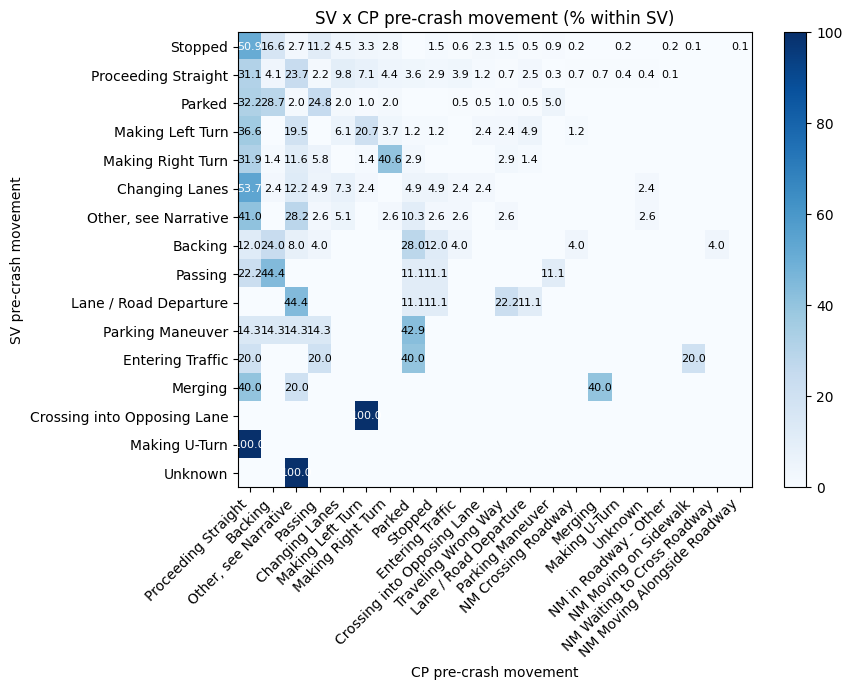

In [22]:
# Heatmap
cui.plot_pre_crash_movement_heatmap(treated_df, normalize='rows',
                                    title='SV x CP pre-crash movement (% within SV)')



In [23]:
# Custom columns if needed
cui.pre_crash_movement_pairs(
    treated_df,
    sv_col='SV Pre-Crash Movement',
    cp_col='CP Pre-Crash Movement',
    include_unknown=False,
)

,sv_move,cp_move,count,pct_of_rows,pct_of_pairs
0,Stopped,Proceeding Straight,542,23.12,24.17
1,Proceeding Straight,Proceeding Straight,214,9.13,9.55
2,Stopped,Backing,177,7.55,7.89
3,Proceeding Straight,"Other, see Narrative",163,6.95,7.27
4,Stopped,Passing,119,5.08,5.31
5,Proceeding Straight,Changing Lanes,67,2.86,2.99
6,Parked,Proceeding Straight,65,2.77,2.90
7,Parked,Backing,58,2.47,2.59
8,Parked,Passing,50,2.13,2.23
9,Proceeding Straight,Making Left Turn,49,2.09,2.19


## Checking redacted narrative

In [8]:
ads_df['Narrative'].value_counts()

Narrative
[REDACTED, MAY CONTAIN CONFIDENTIAL BUSINESS INFORMATION]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

In [9]:
temp_df = treated_df[treated_df['Narrative'] == '[REDACTED, MAY CONTAIN CONFIDENTIAL BUSINESS INFORMATION]'].copy()
print(temp_df.shape)

temp_df[entity_column].value_counts(dropna=False)

(31, 174)


master_entity
Tesla                       15
Argo AI                      9
Colorado School of Mines     2
Mercedes Benz                1
Motional                     1
Beep                         1
Cruise                       1
Chrysler (fca US Llc)        1
Name: count, dtype: int64

In [13]:
temp_df[['Narrative', entity_column, 'Report Submission Date']].sort_values(entity_column, ascending=False)

,Narrative,master_entity,Report Submission Date
60,"[REDACTED, MAY CONTAIN CONFIDENTIAL BUSINESS I...",Tesla,SEP-2025
61,"[REDACTED, MAY CONTAIN CONFIDENTIAL BUSINESS I...",Tesla,SEP-2025
62,"[REDACTED, MAY CONTAIN CONFIDENTIAL BUSINESS I...",Tesla,SEP-2025
287,"[REDACTED, MAY CONTAIN CONFIDENTIAL BUSINESS I...",Tesla,OCT-2025
288,"[REDACTED, MAY CONTAIN CONFIDENTIAL BUSINESS I...",Tesla,OCT-2025
515,"[REDACTED, MAY CONTAIN CONFIDENTIAL BUSINESS I...",Tesla,NOV-2025
1484,"[REDACTED, MAY CONTAIN CONFIDENTIAL BUSINESS I...",Tesla,JAN-2026
1485,"[REDACTED, MAY CONTAIN CONFIDENTIAL BUSINESS I...",Tesla,JAN-2026
1486,"[REDACTED, MAY CONTAIN CONFIDENTIAL BUSINESS I...",Tesla,JAN-2026
1487,"[REDACTED, MAY CONTAIN CONFIDENTIAL BUSINESS I...",Tesla,JAN-2026


In [14]:
treated_df[treated_df[entity_column] == 'Tesla']['Narrative'].value_counts(dropna=False)

Narrative
[REDACTED, MAY CONTAIN CONFIDENTIAL BUSINESS INFORMATION]    15
Name: count, dtype: int64